In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [8]:
df['loan_status'].describe()

count          4269
unique            2
top        Approved
freq           2656
Name: loan_status, dtype: object

In [9]:
print(df["loan_status"].unique())

[' Approved' ' Rejected']


In [10]:
df["loan_status"] = df["loan_status"].str.strip()

In [11]:
df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [12]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['loan_status']):
    x_train = df.loc[train_index]
    x_test = df.loc[test_index]

In [14]:
y_train = x_train[['loan_status']]
y_test = x_test[['loan_status']]

In [15]:
drop_attribs = ['loan_id', 'loan_status']

for dataset in (x_train, x_test):
    dataset.drop(drop_attribs, axis=1, inplace=True)

In [16]:
df = x_train.copy()

In [17]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1877,4,Graduate,No,4800000,14300000,6,795,5900000,0,11100000,2600000
1729,3,Graduate,Yes,5800000,16700000,18,633,8100000,8400000,14700000,3700000
164,2,Graduate,Yes,8100000,22300000,18,737,22300000,12600000,27000000,7300000
2298,2,Not Graduate,Yes,4400000,13900000,6,810,13200000,4200000,15000000,5200000
2461,5,Graduate,No,6500000,24800000,8,779,7000000,9600000,15700000,8800000


In [18]:
y_train

,loan_status
1877,1
1729,1
164,1
2298,1
2461,1
...,...
1386,0
2913,1
4072,1
361,1


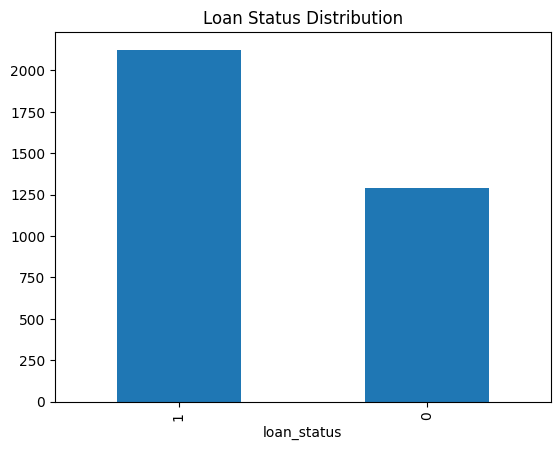

In [19]:
y_train["loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

In [20]:
y_test

,loan_status
2856,0
3176,0
477,0
4023,1
134,1
...,...
629,0
2916,1
3688,0
95,1


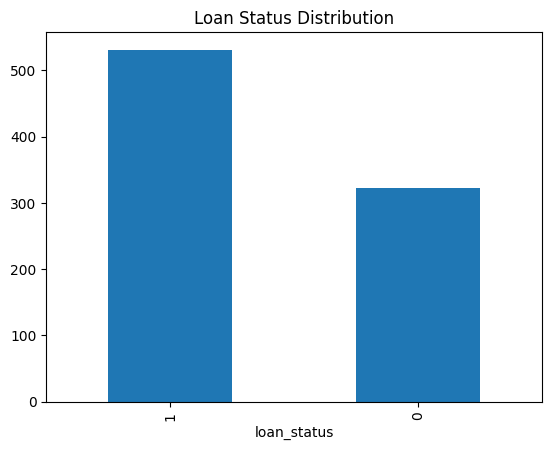

In [21]:
y_test["loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

In [22]:
loan_num = df.select_dtypes(include=(np.number))

In [23]:
loan_num.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1877,4,4800000,14300000,6,795,5900000,0,11100000,2600000
1729,3,5800000,16700000,18,633,8100000,8400000,14700000,3700000
164,2,8100000,22300000,18,737,22300000,12600000,27000000,7300000
2298,2,4400000,13900000,6,810,13200000,4200000,15000000,5200000
2461,5,6500000,24800000,8,779,7000000,9600000,15700000,8800000


In [24]:
loan_cat = df.copy()

In [25]:
num_attribs = loan_num.columns.tolist()

In [26]:
loan_cat.drop(num_attribs, axis=1, inplace=True)

In [27]:
loan_cat.head()

,education,self_employed
1877,Graduate,No
1729,Graduate,Yes
164,Graduate,Yes
2298,Not Graduate,Yes
2461,Graduate,No


In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
onehot_encoder = OneHotEncoder()

In [30]:
loan_cat = onehot_encoder.fit_transform(loan_cat)

In [31]:
onehot_encoder.categories_

[array([' Graduate', ' Not Graduate'], dtype=object),
 array([' No', ' Yes'], dtype=object)]

In [32]:
loan_cat = pd.DataFrame(
    loan_cat.toarray(),
    columns = onehot_encoder.get_feature_names_out(),
    index = df.index
)

In [33]:
loan_cat.head()

,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
1877,1.0,0.0,1.0,0.0
1729,1.0,0.0,0.0,1.0
164,1.0,0.0,0.0,1.0
2298,0.0,1.0,0.0,1.0
2461,1.0,0.0,1.0,0.0


In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
loan_num_scaled = scaler.fit_transform(loan_num)

In [37]:
loan_num_scaled

array([[ 0.89071783, -0.09264606, -0.08867674, ..., -1.13730558,
        -0.44443983, -0.73682658],
       [ 0.30110717,  0.26545952,  0.18021761, ...,  0.78599456,
        -0.04838711, -0.39679525],
       [-0.28850349,  1.08910236,  0.80763775, ...,  1.74764462,
         1.30479299,  0.71603457],
       ...,
       [ 0.30110717,  0.08640673,  0.31466478, ...,  0.32806595,
        -0.3894325 , -0.42770719],
       [-1.46772481, -0.23588829, -0.1110846 , ..., -0.83965199,
        -0.6974735 ,  0.37600323],
       [ 0.30110717,  1.33977627,  0.59476306, ...,  1.47288746,
         1.43681056,  2.10707184]], shape=(3415, 9))

In [42]:
loan_num = pd.DataFrame(loan_num_scaled, columns=loan_num.columns, index=df.index)

In [43]:
loan_num.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1877,0.890718,-0.092646,-0.088677,-0.850759,1.131102,-0.235163,-1.137306,-0.444440,-0.736827
1729,0.301107,0.265460,0.180218,1.243433,0.194245,0.107588,0.785995,-0.048387,-0.396795
164,-0.288503,1.089102,0.807638,1.243433,0.795684,2.319895,1.747645,1.304793,0.716035
2298,-0.288503,-0.235888,-0.133492,-0.850759,1.217848,0.902149,-0.175656,-0.015383,0.066884
2461,1.480328,0.516133,1.087736,-0.501727,1.038573,-0.063787,1.060752,0.061628,1.179714
